In [1]:
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 80% !important; }</style>"))

# Import lots of stuff

import logging
import threading
import json 
import itertools
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ibm_db
#import shap

#from pandas_profiling import ProfileReport
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
import seaborn as seabornInstance

from sqlalchemy import Column, Integer, String, Float, DateTime, Boolean, func
from iotfunctions import base
from iotfunctions import bif
from iotfunctions.db import Database
from iotfunctions import entity
from iotfunctions import metadata
from iotfunctions.metadata import EntityType  
from iotfunctions.enginelog import EngineLogging
from iotfunctions.dbtables import FileModelStore
from iotfunctions import estimator
from iotfunctions.ui import (UISingle, UIMultiItem, UIFunctionOutSingle,
                 UISingleItem, UIFunctionOutMulti, UIMulti, UIExpression,
                 UIText, UIStatusFlag, UIParameters)
from iotfunctions.dbtables import FileModelStore, DBModelStore
#from mmfunctions.anomaly import (SaliencybasedGeneralizedAnomalyScore, SpectralAnomalyScore,
#                 FFTbasedGeneralizedAnomalyScore, KMeansAnomalyScore, SimpleRegressor)
from iotfunctions.anomaly import GBMRegressor
from iotfunctions.experimental import TSFMZeroShotScorer

import datetime as dt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import MinCovDet
from sklearn import metrics
import scipy as sp
import scipy.fftpack
#import skimage as ski  
#from skimage import util as skiutil # for nifty windowing
import pyod as pyod

2025-05-09 10:40:13.332930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746780013.543720  606427 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746780013.599131  606427 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 10:40:14.019698: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [7]:
df = pd.read_csv('data/AzureAnomalysample.csv', parse_dates=['timestamp'])
df = df.sort_values(by='timestamp')

In [8]:
# Make sure we have two different entities to check by entity grouping

#df = df.drop(columns=['entity.1','entity.2'])

df2 = df.copy()
df2['entity'] = 'myentity2'
df['entity'] = 'myentity'
df = pd.concat((df,df2))

df = df.set_index(['entity','timestamp'])

In [10]:
# Need a Database facade for testing
db_schema=None
class DatabaseDummy:
    tenant_id = '###_IBM_###'
    db_type = 'db2'
    model_store = FileModelStore('./')
    def _init(self):
        return
db = DatabaseDummy()

print (db.tenant_id)


INFO:p-606427:t-132451171098752:dbtables.py:__init__:Init FileModelStore with path: ./


###_IBM_###


In [11]:
# Adding a very simple 2nd feature
df['sine'] = np.sin(np.arange(8000)/100)

In [12]:
#plt.plot(np.sin(df3.index.get_level_values(1).values.astype(int)/100000000)[:300])

#plt.plot(np.sin((df3.index.get_level_values(1).values.astype(int) - df3.index.get_level_values(1).values.astype(int)[0])/10000000000)[0:100])
#plt.plot(np.sin(df3.index.get_level_values(1).values.astype(int)/10000000000)[0:100])



In [13]:
# Initializing the KPI scoring function

EngineLogging.configure_console_logging(logging.DEBUG)
jobsettings = { 'db': db, '_db_schema': 'public', 'save_trace_to_file' : True}

#zcorer = TSFMZeroShotScorer(input_items=['value','sine'],output_items=['value_fore','sine_fore'], context=512, horizon=96, watsonx_auth=None)
zcorer = TSFMZeroShotScorer(input_items=['sine','value'],output_items=['sine_fore','value_fore'], context=512, horizon=96, watsonx_auth=None)
#zcorer = TSFMZeroShotScorer(input_items=['sine'],output_items=['sine_fore'], context=512, horizon=96, watsonx_auth=None)
   


DEBUG:p-606427:t-132451171098752:enginelog.py:configure_console_logging:Console logging has been configured. Level = 10


2025-05-09T10:43:31.864 DEBUG iotfunctions.enginelog.configure_console_logging Console logging has been configured. Level = 10


DEBUG:p-606427:t-132451171098752:experimental.py:__init__:['sine', 'value'], ['sine_fore', 'value_fore'], 512, 96


2025-05-09T10:43:31.870 DEBUG iotfunctions.experimental.__init__ ['sine', 'value'], ['sine_fore', 'value_fore'], 512, 96


DEBUG:p-606427:t-132451171098752:base.py:__init__:['sine', 'value']


2025-05-09T10:43:31.873 DEBUG iotfunctions.base.__init__ ['sine', 'value']


DEBUG:p-606427:t-132451171098752:bif.py:__init__:['sine', 'value']


2025-05-09T10:43:31.877 DEBUG iotfunctions.bif.__init__ ['sine', 'value']


In [14]:
# Overwrite the original call_local_model() method for testing purposes
#  as now it is the same as the code in iotfunctions/experimental.py
#  but this approach allows us to change it without restarting the whole notebook

import torch
from torch.nn import functional as f
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

test_input = None
test_input_unfold = None
test_output = None
test_output_fold = None

# inference on local model 
def call_local_model_ext(self, df):
    logger.info('call local model ----- ')

    logger.debug('df columns  ' + str(df.columns))
    logger.debug('df index ' + str(df.index.names))

    # size of the df should be fine
    full_length = self.context + self.horizon
    df[self.output_items] = 0

    if self.model is not None:

        logger.debug('Forecast ' + str(df.shape[0]/self.use_horizon) + ' times')

        # for default overlap (use_horizon) we better use unfold

        # so we get all relevant features in a tensor with dimensions
        #     features x time
        inputtensor_ = torch.from_numpy(df[self.input_items].values).to(torch.float32)

        if len(list(inputtensor_.shape)) < 2:
            inputtensor_ = inputtensor_[None, :]

        global test_input
        test_input = inputtensor_
        print("we got", inputtensor_.T.shape)
        # and slice it up along the time dimension (potentially ditching last elements)
        #   dimensions: features x slices x time
        inputtensor = inputtensor_.T.unfold(1, self.context, self.use_horizon)

        global test_input_unfold
        test_input_unfold = inputtensor
        print("we unfolded it into", inputtensor.shape)

        #print(inputtensor[0,14,:])

        # TTM expects the dimensions permuted: features x time x slices
        # and we get a result tensor back with dimensions features x forecast_time x slices
        outputtensor = self.model(inputtensor.permute(0,2,1))['prediction_outputs']
        print("the model produced", outputtensor.shape)

        global test_output
        test_output = outputtensor
        #print(outputtensor[0,:,14])

        # we fold the sequence of forecasts back into its original shape: features x time
        fold_back = f.fold(outputtensor, (1, self.use_horizon * (outputtensor.shape[2] + 1)) ,
                      kernel_size=(1, outputtensor.shape[1]), stride=(1,self.use_horizon)).squeeze()
        #print(fold_back[512:1024])
        #fold_back2 = f.fold(outputtensor, (1, 48 * (157+1)), kernel_size=(1, 96), stride=(1,48))
        print("we folded it", fold_back.shape)
        #print(fold_back[1,0:100])

        global test_output_fold
        test_output_fold = fold_back.detach().numpy().astype(float)

        try:
            nr_features = df[self.output_items].shape[1]
            if len(list(fold_back.shape)) < 2:
                #fold_back = fold_back[None, :]
                nr_features = 1
                forecast_tensor = fold_back.detach().resize_(len(df.index) - self.context)
            else:
                forecast_tensor = fold_back.detach().resize_(fold_back.shape[0], len(df.index) - self.context).permute(1,0)
            forecast = forecast_tensor.numpy().astype(float)
            #if nr_features > 1:
            #    forecast = forecast.reshape(-1, nr_features)
            print(nr_features, forecast.shape)
            #forecast = fold_back.detach().numpy().astype(float)
            print("finally", forecast.shape, df.loc[df[self.context:].index, self.output_items].shape)
            df.loc[df[self.context:].index, self.output_items] = forecast
        except Exception as e:
            # indexing issue shouldn't happen
            logger.debug('Issue with:' + str(self.use_horizon) + '    ' + str(e))
            pass

    return df

zcorer.call_local_model = call_local_model_ext.__get__(zcorer, TSFMZeroShotScorer)


In [15]:

# Execute the function

et2 = zcorer._build_entity_type(columns = [Column('GunPressure_Kmeans',Float())], **jobsettings)
et2._timestamp = 'timestamp'
et2._entity_id = 'entity'
zcorer.execute_by = ['entity']
zcorer._entity_type = et2
#zcorer.auto_train = True
df3 = zcorer.execute(df=df)

DEBUG:p-606427:t-132451171098752:metadata.py:__init__:Initializing new entity type using iotfunctions 9.1.1


2025-05-09T10:45:12.858 DEBUG iotfunctions.metadata.__init__ Initializing new entity type using iotfunctions 9.1.1


DEBUG:p-606427:t-132451171098752:util.py:__init__:Starting trace


2025-05-09T10:45:12.863 DEBUG iotfunctions.util.__init__ Starting trace


DEBUG:p-606427:t-132451171098752:util.py:__init__:Trace name: auto_trace_test_entity_for_TSFMZeroShotScorer_20250509084512


...

the model produced torch.Size([2, 96, 73])
we folded it torch.Size([2, 3552])
2 (3488, 2)
finally (3488, 2) (3488, 2)
2025-05-09T10:45:17.609 DEBUG iotfunctions.base.merge_expanded_frame_by_entity Nothing to merge


DEBUG:p-606427:t-132451171098752:bif.py:execute:InvokeWML results:              value         sine    sine_fore   value_fore
count  8000.000000  8000.000000  8000.000000  8000.000000
mean      4.264336     0.013942    -0.066541     7.619570
std       1.484151     0.706485     1.365745     3.978274
min       0.000000    -0.999999    -2.451499    -2.372863
25%       3.062500    -0.693238    -1.317375     5.196837
50%       4.000000     0.031679     0.000000     7.894748
75%       5.437500     0.718188     1.190099    10.600323
max      10.750000     1.000000     1.928084    14.290846


2025-05-09T10:45:17.642 DEBUG iotfunctions.bif.execute InvokeWML results:              value         sine    sine_fore   value_fore
count  8000.000000  8000.000000  8000.000000  8000.000000
mean      4.264336     0.013942    -0.066541     7.619570
std       1.484151     0.706485     1.365745     3.978274
min       0.000000    -0.999999    -2.451499    -2.372863
25%       3.062500    -0.693238    -1.317375     5.196837
50%       4.000000     0.031679     0.000000     7.894748
75%       5.437500     0.718188     1.190099    10.600323
max      10.750000     1.000000     1.928084    14.290846


DEBUG:p-606427:t-132451171098752:bif.py:execute:InvokeWML columns Index(['value', 'sine', 'sine_fore', 'value_fore'], dtype='object'), index ['entity', 'timestamp']


2025-05-09T10:45:17.645 DEBUG iotfunctions.bif.execute InvokeWML columns Index(['value', 'sine', 'sine_fore', 'value_fore'], dtype='object'), index ['entity', 'timestamp']


In [16]:
# less debugging now to make plotting less of a nuisance
# dump result df to sanity check results

EngineLogging.configure_console_logging(logging.INFO)
df3

value      sine  sine_fore  value_fore
entity    timestamp                                                   
myentity  2017-10-09 20:32:00  3.0000  0.000000   0.000000    0.000000
          2017-10-09 20:33:00  3.0000  0.010000   0.000000    0.000000
          2017-10-09 20:34:00  3.0000  0.019999   0.000000    0.000000
          2017-10-09 20:35:00  3.0000  0.029996   0.000000    0.000000
          2017-10-09 20:36:00  3.0000  0.039989   0.000000    0.000000
...                               ...       ...        ...         ...
myentity2 2017-10-12 22:17:00  2.1875 -0.987129  -2.218313    6.843696
          2017-10-12 22:18:00  2.1250 -0.988679  -2.228057    6.834942
          2017-10-12 22:19:00  2.0000 -0.990130  -2.238756    6.853787
          2017-10-12 22:20:00  2.0000 -0.991482  -2.252499    6.864659
          2017-10-12 22:21:00  2.0625 -0.992735  -2.269004    6.881506

[8000 rows x 4 columns]

<Axes: xlabel='timestamp'>

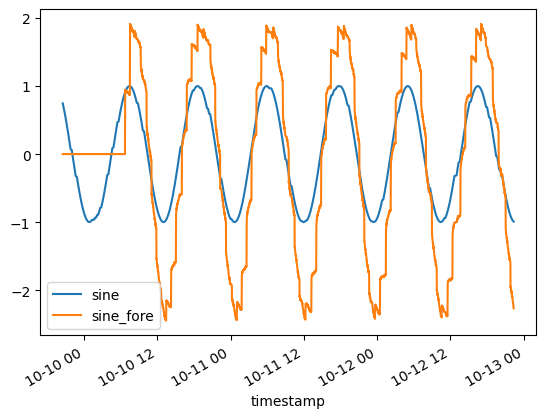

In [17]:
#df3.loc['myentity2'][['sine','sine_fore']][500:600].plot()
df3.loc['myentity2'][['sine','sine_fore']].plot()
#df3.loc['myentity2'][['value','value_fore']].plot()

In [99]:
#df3.loc['myentity2']['sine_fore'][520:580]

In [74]:
out = test_output.detach().numpy().astype(float)

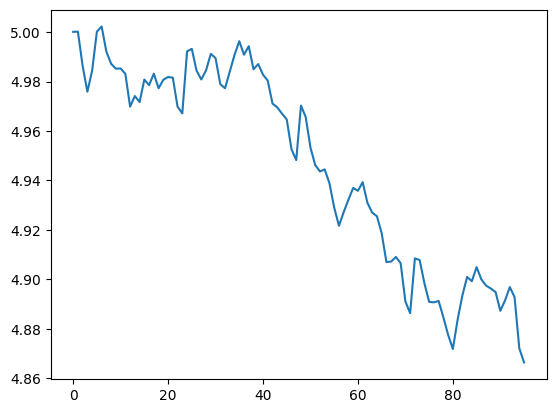

In [75]:
plt.plot(out[0,:,0])

In [77]:
test_output_fold[0,0:20]

array([5.00009489, 5.00017691, 4.98633099, 4.97588634, 4.98440075,
       5.00016975, 5.0022645 , 4.99209738, 4.98719311, 4.98519802,
       4.98528481, 4.98309231, 4.96984482, 4.974123  , 4.97169876,
       4.98081017, 4.97853756, 4.98318911, 4.97728252, 4.980721  ])